# 02. FinBERT Sentiment Scoring

Scores all collected news headlines using `ProsusAI/finbert`.

**Output:** `data/processed/news_sentiment.csv`

Neutral filter (PRD §4.3.1):
- `neutral_prob ≥ 0.5`  OR
- `|positive_prob - negative_prob| < 0.15`

Filtered articles are flagged `is_valid=False` and excluded from correlation analysis.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import matplotlib.pyplot as plt
import pandas as pd

from src.collector import load_all_news
from src.sentiment import run_sentiment_pipeline, load_sentiment_results, sentiment_summary

## 1. Load News Data

In [2]:
news_df = load_all_news()
print(f'News records loaded: {len(news_df):,}')
news_df.head(3)

2026-04-20 17:00:15,718 [INFO] Loaded 30 news records from 1 files


News records loaded: 30


,title,url,source,published_at
0,Ether accumulation wallet balances increased b...,https://cointelegraph.com/news/ether-accumulat...,cointelegraph,2026-04-17 19:14:41+00:00
1,US Senator asks for Binance monitor update ami...,https://cointelegraph.com/news/us-senator-bina...,cointelegraph,2026-04-17 19:22:53+00:00
2,Polymarket odds of Hormuz Strait traffic norma...,https://cointelegraph.com/news/polymarket-stra...,cointelegraph,2026-04-17 21:12:19+00:00


## 2. Run FinBERT Sentiment Pipeline

> First run downloads the model (~500 MB). Subsequent runs use the local cache.
> On CPU: ~1,000 headlines / 5 min.

In [ ]:
sentiment_df = run_sentiment_pipeline(news_df, batch_size=64)
print(f'Scoring complete. Rows: {len(sentiment_df):,}')
sentiment_df.head(5)

2026-04-20 17:00:15,749 [INFO] Using CPU


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

C:\Users\조동희\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\조동희\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Device set to use cpu
2026-04-20 17:08:57,272 [INFO] FinBERT pipeline loaded on cpu
2026-04-20 17:08:58,127 [INFO]   scored 30 / 30
2026-04-20 17:08:58,143 [INFO] Sentiment results saved → C:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\data\processed\news_sentiment.csv  (valid: 17 / 30)


Scoring complete. Rows: 30


,title,url,source,published_at,positive_prob,neutral_prob,negative_prob,score,is_valid,sentiment_label
0,Ether accumulation wallet balances increased b...,https://cointelegraph.com/news/ether-accumulat...,cointelegraph,2026-04-17 19:14:41+00:00,0.861469,0.118142,0.020388,0.841081,True,positive
1,US Senator asks for Binance monitor update ami...,https://cointelegraph.com/news/us-senator-bina...,cointelegraph,2026-04-17 19:22:53+00:00,0.116035,0.686303,0.197663,-0.081628,False,neutral
2,Polymarket odds of Hormuz Strait traffic norma...,https://cointelegraph.com/news/polymarket-stra...,cointelegraph,2026-04-17 21:12:19+00:00,0.949984,0.025555,0.024461,0.925522,True,positive
3,Russia introduces bill to criminalize unregist...,https://cointelegraph.com/news/russia-criminal...,cointelegraph,2026-04-17 21:33:01+00:00,0.083810,0.580970,0.335220,-0.251409,False,neutral
4,Worldcoin tanks 13% as World’s iris-scanning t...,https://cointelegraph.com/news/worldcoin-falls...,cointelegraph,2026-04-18 00:49:26+00:00,0.945141,0.039707,0.015152,0.929989,True,positive


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
2026-04-20 17:08:58,918 [WARNING] Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


## 3. Sentiment Summary Statistics

In [4]:
summary = sentiment_summary(sentiment_df)
for k, v in summary.items():
    print(f'  {k:28s}: {v}')

2026-04-20 17:08:58,215 [INFO] Sentiment summary — total: 30 | valid: 17 | pos: 7 | neg: 10 | neutral: 13 (43.3%)


  total                       : 30
  valid_non_neutral           : 17
  positive                    : 7
  negative                    : 10
  neutral_filtered            : 13
  neutral_pct                 : 43.3
  mean_score_valid            : -0.0879


## 4. Sentiment Distribution Pie Chart

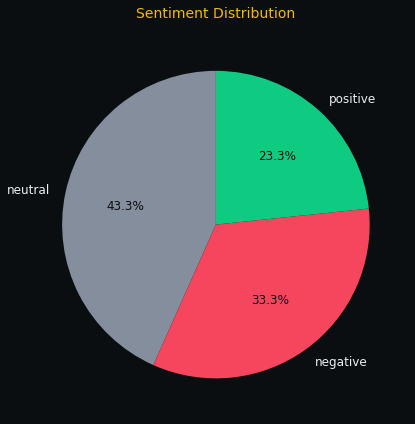

In [5]:
counts = sentiment_df['sentiment_label'].value_counts()
colors = {'positive': '#0ecb81', 'negative': '#f6465d', 'neutral': '#848e9c'}
clr = [colors.get(l, '#fff') for l in counts.index]

fig, ax = plt.subplots(figsize=(6, 6), facecolor='#0b0e11')
ax.set_facecolor('#0b0e11')
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=clr, startangle=90,
    textprops={'color': '#eaecef', 'fontsize': 12},
)
for at in autotexts:
    at.set_color('#0b0e11')
ax.set_title('Sentiment Distribution', color='#f0b90b', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 5. Score Distribution Histogram

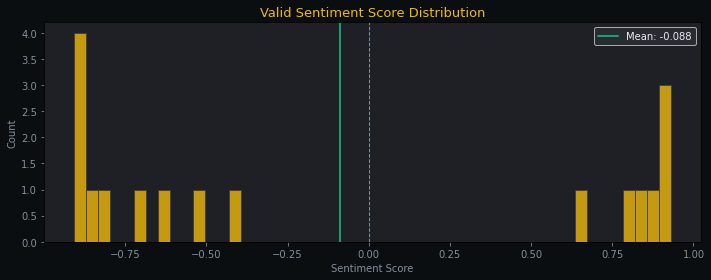

In [6]:
valid = sentiment_df[sentiment_df['is_valid']]

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0b0e11')
ax.set_facecolor('#1e2026')
ax.hist(valid['score'], bins=50, color='#f0b90b', alpha=0.8, edgecolor='#373d47')
ax.axvline(0, color='#848e9c', linestyle='--', linewidth=1)
ax.axvline(valid['score'].mean(), color='#0ecb81', linestyle='-', linewidth=1.5,
           label=f"Mean: {valid['score'].mean():.3f}")
ax.set_xlabel('Sentiment Score', color='#848e9c')
ax.set_ylabel('Count', color='#848e9c')
ax.set_title('Valid Sentiment Score Distribution', color='#f0b90b', fontsize=13)
ax.tick_params(colors='#848e9c')
ax.legend(facecolor='#2b2f36', labelcolor='#eaecef')
plt.tight_layout()
plt.show()

## 6. Load Saved Results (if already run)

In [7]:
# saved_df = load_sentiment_results()
# print(saved_df.shape)
# saved_df.tail(3)

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]